# Impact of Fitness Goals On Health Outcomes
### Exploratory Data Analysis

**Study Questions:**
1. Does setting fitness goals in Google Fit positively impact health outcomes?
2. How do user behaviours compare to their pre-goal baseline?


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print('Libraries loaded')

Libraries loaded


### Import datasets


In [65]:
daily = pd.read_csv("../raw_data/daily_metrics.csv")
participants = pd.read_csv("../raw_data/participants.csv")
weekly = pd.read_csv("../raw_data/weekly_summary.csv")

daily.head()


,participant_id,date,day_offset,phase,is_weekend,steps,distance_km,active_minutes,calories_burned,resting_heart_rate,sleep_hours,sleep_quality_1_10,weight_kg,goal_achieved
0,P001,2024-01-01,-60,pre_goal,0,12899,9.83,61,2518,61,7.5,6.1,83.9,NaN
1,P001,2024-01-02,-59,pre_goal,0,11821,9.01,60,2648,61,7.6,8.1,83.8,NaN
2,P001,2024-01-03,-58,pre_goal,0,12102,9.22,56,2444,63,7.8,6.0,84.1,NaN
3,P001,2024-01-04,-57,pre_goal,0,10965,8.36,65,2446,63,7.3,7.0,84.2,NaN
4,P001,2024-01-05,-56,pre_goal,0,13176,10.04,70,2679,63,7.9,7.6,84.0,NaN


In [66]:
participants.head()


,participant_id,age,gender,height_m,baseline_weight_kg,baseline_bmi,fitness_level,goal_set,goal_type,goal_value
0,P001,27,Male,1.90,84.0,23.4,High,True,Calories Burned,2689.1
1,P002,45,Male,1.91,80.0,22.0,High,False,NaN,NaN
2,P003,42,Female,1.62,76.5,29.0,Low,True,Daily Steps,8669.5
3,P004,36,Female,1.61,69.5,26.8,Moderate,True,Daily Steps,10562.6
4,P005,36,Female,1.58,63.6,25.3,Low,True,Daily Steps,7376.9


In [67]:
weekly.head()

,participant_id,study_week,phase,steps,distance_km,active_minutes,calories_burned,resting_heart_rate,sleep_hours,sleep_quality_1_10,weight_kg,goal_set,fitness_level,age,gender
0,P001,-9,pre_goal,11946.75,9.10,60.50,2514.00,62.00,7.55,6.80,84.00,True,High,27,Male
1,P001,-8,pre_goal,9705.86,7.40,63.29,2713.86,61.00,7.64,7.76,83.84,True,High,27,Male
2,P001,-7,pre_goal,11318.00,8.62,62.71,2681.57,62.86,7.57,7.50,83.96,True,High,27,Male
3,P001,-6,pre_goal,9914.86,7.56,61.14,2683.86,60.57,7.43,7.07,84.03,True,High,27,Male
4,P001,-5,pre_goal,10217.86,7.79,57.57,2736.57,63.00,7.31,6.89,84.03,True,High,27,Male


### Dataset Overview


Total participants = 100
Male participants = 52
Female participants = 48
 
Total Goal Setters = 71
Female Goal Setters =  36
Male Goal Setters =  35
 
%_male_goal_setters =  67.31 % of males are goal setters
%_female_goal_setters =  75.0 % of females are goal setters
 
Number of participants with multiple goals: 0


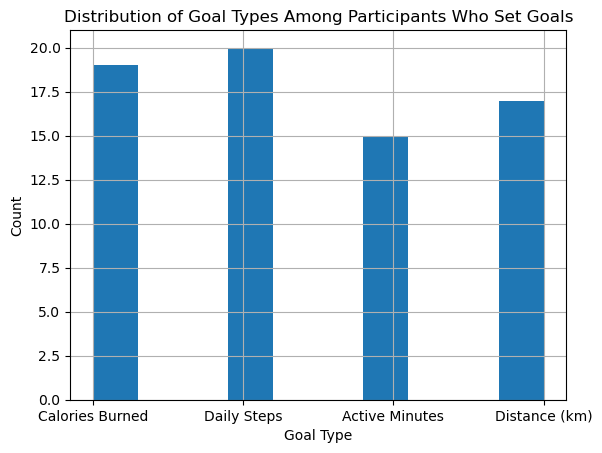

In [ ]:
total_participants = participants['participant_id'].nunique()
total_males = participants[participants['gender'] == 'Male'].participant_id.nunique()
total_females = participants[participants['gender'] == 'Female'].participant_id.nunique()
total_goal_setters = participants[participants['goal_set'] == True].participant_id.nunique()
total_female_goal_setters = participants[(participants['goal_set'] == True) & (participants['gender'] == 'Female')].participant_id.nunique()
total_male_goal_setters = participants[(participants['goal_set'] == True) & (participants['gender'] == 'Male')].participant_id.nunique()



print("Total participants =", participants['participant_id'].nunique())
print("Male participants =", total_males)
print("Female participants =", total_females)

print(" ")

print('Total Goal Setters =', total_goal_setters)
print('Female Goal Setters = ', total_female_goal_setters)
print('Male Goal Setters = ', total_male_goal_setters) 

print(" ")

print('%_male_goal_setters = ', round(total_male_goal_setters/total_males * 100, 2), '% of males are goal setters')
print('%_female_goal_setters = ', round(total_female_goal_setters/total_females * 100, 2), '% of females are goal setters')

#Goal types
goal_types = participants['goal_type'].value_counts()
participants['goal_type'].hist()
plt.title('Distribution of Goal Types Among Participants Who Set Goals')
plt.xlabel('Goal Type')
plt.ylabel('Count')
plt.plot()


print(" ")

dup_goal = participants[['participant_id', 'goal_type']].groupby('participant_id').count()
print("Number of participants with multiple goals:", len(dup_goal[dup_goal['goal_type'] > 1]))


0